## Máster en Big Data y Data Science

### Metodologías de gestión y diseño de proyectos de big data

#### AP2 - Modelado y evaluación

---

En esta libreta se realiza la experimentación para generación del modelo de predicción objetivo del proyecto y la evaluación del mismo.
La versión del dataset a utilizar es la obtenida a partir de las operaciones de transformación.

In [1]:
# Se importan las librerías necesarias y se suprimen las advertencias
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore',category=FutureWarning)
warnings.filterwarnings('ignore',category=UserWarning)



from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_validate


# #################### (EXTRA) #########################
from sklearn.ensemble import HistGradientBoostingClassifier

In [2]:
# Implementacion de MLFlow
from datetime import datetime
import numpy as np


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

# mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_tracking_uri("sqlite:///mlflow.db") # La version mas reciente de MLFlow (3.14.0 actualemente) recomeinda migrar al uso de la base de datos.
mlflow.set_experiment("13MBID - Experimentacion original (MVP modificado con Undersampling)")

<Experiment: artifact_location='file:c:/Users/EinKiGa/Desktop/13MBID_OCT2526/notebooks/mlruns/1', creation_time=1783307294599, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783307294599, lifecycle_stage='active', name='13MBID - Experimentacion original (MVP modificado con Undersampling)', tags={}, trace_location=None, workspace='default'>

In [3]:
# Lectura de los datos
df = pd.read_csv('../data/processed/datos_integrados.csv')
df.head(5)

,duracion_credito,situacion_vivienda,ingresos,objetivo_credito,pct_ingreso,tasa_interes,estado_credito,falta_pago,antiguedad_cliente,estado_civil,...,genero,limite_credito_tc,nivel_educativo,personas_a_cargo,capacidad_pago,ratio_endeudamiento,operaciones_mensuales,gasto_transaccion_promedio,presion_financiera,antiguedad_relativa
0,3,ALQUILER,59000,PERSONAL,0.59,16.02,1,Y,36.0,CASADO,...,M,4010.0,UNIVERSITARIO_COMPLETO,2.0,0.593220,0.372340,2.000000,45.333333,28.493017,5.590909
1,2,PROPIA,9600,EDUCACIÓN,0.10,11.14,0,N,39.0,CASADO,...,M,12691.0,SECUNDARIO_COMPLETO,3.0,0.104167,0.094340,3.500000,27.238095,7.619167,0.238095
2,3,HIPOTECA,9600,SALUD,0.57,12.87,1,N,44.0,SOLTERO,...,F,8256.0,UNIVERSITARIO_COMPLETO,5.0,0.572917,0.364238,2.750000,39.121212,27.634479,0.040000
3,2,ALQUILER,65500,SALUD,0.53,15.23,1,N,36.0,CASADO,...,M,3418.0,UNIVERSITARIO_COMPLETO,3.0,0.534351,0.348259,1.666667,94.350000,38.502092,0.173913
4,4,ALQUILER,54400,SALUD,0.55,14.27,1,Y,54.0,CASADO,...,M,9095.0,DESCONOCIDO,1.0,0.643382,0.391499,2.166667,50.538462,23.185919,0.333333


In [4]:
def reporte_descripcion_dataset(df):
    columnas = df.columns
    print(f"Columnas del dataset ({df.shape[1]}):\n")
    for col in columnas:
        print(col)
    print(f"\nCantidad de filas: {df.shape[0]}")

print("Descripción del dataset 'datos_integrados.csv':\n")
reporte_descripcion_dataset(df)

Descripción del dataset 'datos_integrados.csv':

Columnas del dataset (21):

duracion_credito
situacion_vivienda
ingresos
objetivo_credito
pct_ingreso
tasa_interes
estado_credito
falta_pago
antiguedad_cliente
estado_civil
estado_cliente
genero
limite_credito_tc
nivel_educativo
personas_a_cargo
capacidad_pago
ratio_endeudamiento
operaciones_mensuales
gasto_transaccion_promedio
presion_financiera
antiguedad_relativa

Cantidad de filas: 10123


In [5]:
# Preprocesameinto de datos

# Ajuste customizado de datos
# Ajuste de dato: falta_pago debe convertirse explicitamente a binaria para que sea mas facil a los algoritmos hacer la clasificacion
# Se convierte la variable objetivo a binaria: 1 = falta de pago (Y), 0 = sin falta (N)
df["falta_pago"] = df["falta_pago"].map({"Y": 1, "N": 0})

In [6]:
# Se divide el dataset en variables predictoras y variable objetivo
target = "falta_pago"

features_X = df.drop(columns=[target])
labels_y = df[target]

print("Dimensiones X:", features_X.shape)
print("Dimensiones y:", labels_y.shape)

Dimensiones X: (10123, 20)
Dimensiones y: (10123,)


In [7]:
# Se genera el conjunto de entrenamiento, validación y test con estratificación

# Primero separar test final (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    features_X,
    labels_y,
    test_size=0.10,
    random_state=42,
    stratify=labels_y
)

# Luego separar train y validation (22% del 90% es aprox. el 20% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.22,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (7105, 20)
Validation: (2005, 20)
Test: (1013, 20)


In [8]:
# Se identifican las columnas numéricas y categóricas

num_cols = features_X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = features_X.select_dtypes(include=["object","category"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['duracion_credito', 'ingresos', 'pct_ingreso', 'tasa_interes', 'estado_credito', 'antiguedad_cliente', 'limite_credito_tc', 'personas_a_cargo', 'capacidad_pago', 'ratio_endeudamiento', 'operaciones_mensuales', 'gasto_transaccion_promedio', 'presion_financiera', 'antiguedad_relativa']
Categóricas: ['situacion_vivienda', 'objetivo_credito', 'estado_civil', 'estado_cliente', 'genero', 'nivel_educativo']


In [9]:
# Se verifica la distribución de la variable objetivo en el conjunto de entrenamiento
display(y_train.value_counts())

falta_pago
0    5864
1    1241
Name: count, dtype: int64

In [10]:
# Se crea un pipeline para preprocesamiento de datos

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [11]:
# Se crea un pipeline completo con preprocesamiento y modelo base

baseline = Pipeline([
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_val)

print("Baseline accuracy:", accuracy_score(y_val, y_pred))

Baseline accuracy: 0.8254364089775561


In [12]:
# Se definen los modelos a evaluar
## EXTRA: Se ha incluido HistGradientBoosting
modelos = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "LinearSVC": LinearSVC(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=42,
        class_weight="balanced"   # permite compensar de manera interna el desbalance en 1 (Y) vs 0 (N)
    )
}

In [13]:
# Esquema de trabajo original (antes de implementar MLFlow)
# Se guarda evidencia del estado original como referencia

# Se evaluan los modelos con validación cruzada comparando sus resultados

# resultados = []

# for nombre, modelo in modelos.items():
#     # Se aplica el preprocesamiento
#     pipeline = ImbPipeline([
#         ("prep", preprocessor),
#         ("undersample", RandomUnderSampler(random_state=42)),
#         ("model", modelo)
#     ])

#     # Se evalúan los modelos con validación cruzada
#     scores = cross_validate(
#         pipeline,
#         X_train,
#         y_train,
#         cv=5,
#         scoring=["accuracy", "precision", "recall", "f1", "roc_auc"], # Se incluyen principalmente f1 y roc_auc
#         error_score = "raise"
#     )

#     # Se almacenan los resultados
#     resultados.append({
#         "modelo": nombre,
#         "accuracy_mean": scores["test_accuracy"].mean(),
#         "accuracy_std": scores["test_accuracy"].std(),
#         "precision_mean": scores["test_precision"].mean(),
#         "precision_std": scores["test_precision"].std(),
#         "recall_mean": scores["test_recall"].mean(),
#         "recall_std": scores["test_recall"].std(),
#         "f1_mean": scores["test_f1"].mean(),
#         "f1_std": scores["test_f1"].std(),
#         "roc_auc_mean": scores["test_roc_auc"].mean(),
#         "roc_auc_std": scores["test_roc_auc"].std(),
#     })

# df_resultados = pd.DataFrame(resultados)

# df_resultados.sort_values("roc_auc_mean", ascending=False)

In [ ]:
# Esquema de trabajo integrado con MLFlow


# Función auxiliar para obtener un score continuo y poder calcular ROC AUC.
# Se prioriza `predict_proba`, y si el modelo no lo soporta, se usa `decision_function`.
def _score_for_auc(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return None

# Scorers personalizados para evitar métricas `NaN` cuando un modelo no predice
# la clase positiva en algún fold de validación cruzada.
def _cv_precision(estimator, X, y):
    return precision_score(y, estimator.predict(X), zero_division=0)

def _cv_recall(estimator, X, y):
    return recall_score(y, estimator.predict(X), zero_division=0)

def _cv_f1(estimator, X, y):
    return f1_score(y, estimator.predict(X), zero_division=0)

# Se convierte la variable objetivo (Y/N a 1/0), si es que no fue realizada previamente
if set(y_train.dropna().unique()) == {"N", "Y"}:
    y_train_eval = y_train.map({"N": 0, "Y": 1})
    y_val_eval = y_val.map({"N": 0, "Y": 1})
    y_test_eval = y_test.map({"N": 0, "Y": 1})
else:
    y_train_eval = y_train.copy()
    y_val_eval = y_val.copy()
    y_test_eval = y_test.copy()

# Funcion para la construccion del pipeline de preprocsameinto, undersampling y el metodo a evaluar
def evaluar_y_registrar_mlflow(nombre, modelo):
    # Se aplica el preprocesamiento
    pipeline = ImbPipeline([
        ("prep", preprocessor),
        ("undersample", RandomUnderSampler(random_state=42)),
        ("model", modelo)
    ])

    # Se evalúan los modelos con validación cruzada
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring={
            "accuracy": "accuracy",
            "precision": _cv_precision,
            "recall": _cv_recall,
            "f1": _cv_f1,
            "roc_auc": "roc_auc"
        },
        error_score = "raise"
    )

    # Se entrena el pipeline completo con todos los datos de entrenamiento
    pipeline.fit(X_train, y_train_eval)

    # Predicciones y scores sobre test
    y_test_pred = pipeline.predict(X_test)
    y_test_score = _score_for_auc(pipeline, X_test)
    test_roc_auc = roc_auc_score(y_test_eval, y_test_score) if y_test_score is not None else np.nan

    # Se infiere la firma del modelo para registrar correctamente en MLflow.
    signature = infer_signature(X_train, pipeline.predict(X_train))

    with mlflow.start_run(run_name=f"Experimento_{nombre}_{datetime.now().strftime("%Y%m%d_%H%M%S")}"):
        # Se registran los hiperparámetros del modelo
        mlflow.log_params(modelo.get_params())

        # Se registran parámetros adicionales del experimento
        mlflow.log_params({
            "train_samples": len(X_train),
            "validation_samples": len(X_val),
            "test_samples": len(X_test),
            "balancing_method": "undersampling",
            "cv_folds": 5
        })

        # Métricas promedio y desvío estándar de validación cruzada
        mlflow.log_metrics({
            "cv_accuracy_mean": scores["test_accuracy"].mean(),
            "cv_precision_mean": scores["test_precision"].mean(),
            "cv_recall_mean": scores["test_recall"].mean(),
            "cv_f1_mean": scores["test_f1"].mean(),
            "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
            "cv_accuracy_std": scores["test_accuracy"].std(),
            "cv_precision_std": scores["test_precision"].std(),
            "cv_recall_std": scores["test_recall"].std(),
            "cv_f1_std": scores["test_f1"].std(),
            "cv_roc_auc_std": scores["test_roc_auc"].std()
        })

        mlflow.log_metrics({
            "test_accuracy": accuracy_score(y_test_eval, y_test_pred),
            "test_precision": precision_score(y_test_eval, y_test_pred, zero_division=0),
            "test_recall": recall_score(y_test_eval, y_test_pred, zero_division=0),
            "test_f1": f1_score(y_test_eval, y_test_pred, zero_division=0),
            "test_roc_auc": test_roc_auc
        })

        # Se registra el modelo entrenado en MLflow.
        mlflow.sklearn.log_model(
            pipeline,
            name="model",
            signature=signature,
            skops_trusted_types=[ # De esta maner se evita el error: MlflowException: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types.
                "imblearn.pipeline.Pipeline",
                "imblearn.under_sampling._prototype_selection._random_under_sampler.RandomUnderSampler"
            ]
        )

    # Se devuelve un resumen para construir la tabla comparativa final
    return {
        "modelo": nombre,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    }


resultados = []

for nombre, modelo in modelos.items():
    resultados.append(evaluar_y_registrar_mlflow(nombre, modelo))

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values("roc_auc", ascending=False)

,modelo,accuracy,precision,recall,f1,roc_auc
4,HistGradientBoosting,0.851372,0.546187,0.888787,0.676391,0.945920
0,LogisticRegression,0.844757,0.535835,0.845284,0.655728,0.923009
1,LinearSVC,0.846165,0.538676,0.842055,0.656888,0.922593
2,KNN,0.800844,0.460961,0.821104,0.590328,0.880997
3,DecisionTree,0.822660,0.495975,0.818688,0.617530,0.821091


In [20]:
# Exportar resultado del ranking
df_resultados.to_csv("resultados_modelos.csv", index=False)

In [15]:
# Se entrena el mejor modelo

# mejor_modelo = modelos.get("LinearSVC") # ORIGINAL
mejor_modelo = modelos.get("HistGradientBoosting")

modelo_final = Pipeline([
    ("prep", preprocessor),
    ("model", mejor_modelo)
])

modelo_final.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['duracion_credito','situacion_vivienda','ingresos',..., 'gasto_transaccion_promedio','presion_financiera','antiguedad_relativa']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [16]:
# Se evalúan los resultados en el conjunto de validación

y_val_pred = modelo_final.predict(X_val)

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.97      0.90      0.93      1655
           1       0.65      0.86      0.74       350

    accuracy                           0.90      2005
   macro avg       0.81      0.88      0.84      2005
weighted avg       0.91      0.90      0.90      2005



In [17]:
# Se evalúan los resultados en el conjunto de test

y_test_pred = modelo_final.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94       836
           1       0.67      0.85      0.75       177

    accuracy                           0.90      1013
   macro avg       0.82      0.88      0.84      1013
weighted avg       0.91      0.90      0.90      1013



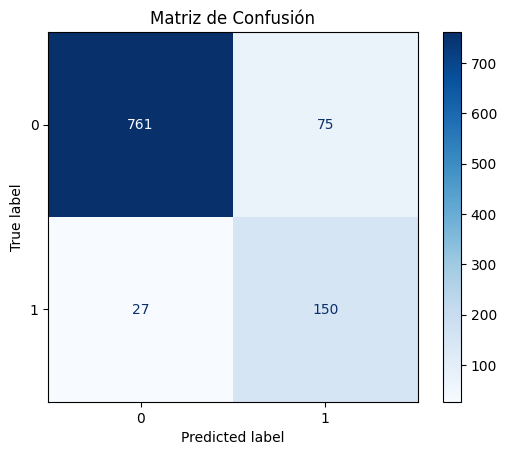

In [18]:
# Se genera una matriz de confusión para el conjunto de test

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusión")
plt.show()